In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer

In [ ]:
import warnings

warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/sample_data/diabetes.csv')

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
df.shape

(768, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


# EDA

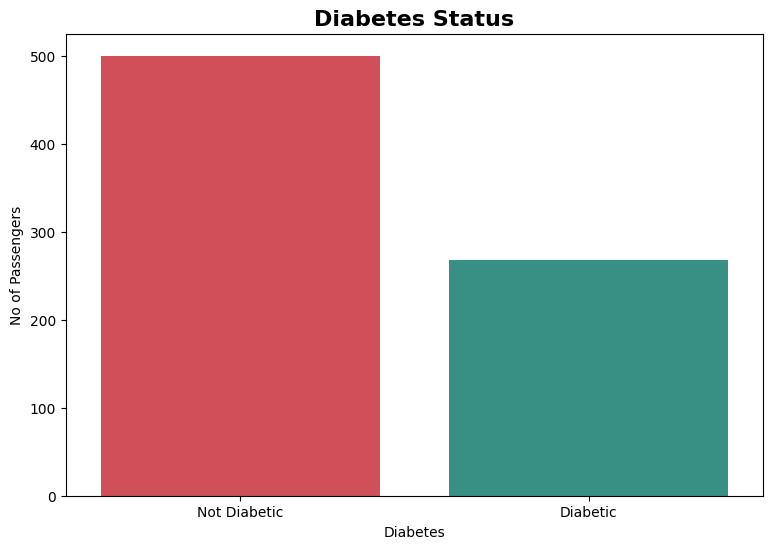

In [ ]:
plt.figure(figsize=(9, 6))
plt.title("Diabetes Status", fontsize=16, fontweight="bold")
plt.xlabel("Diabetes")
plt.ylabel("No of Passengers")

custom_colors = {'0': "#E63946", '1': "#2A9D8F"}
ax = sns.countplot(data=df, x="Outcome", palette=custom_colors)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Not Diabetic", "Diabetic"])

plt.show()


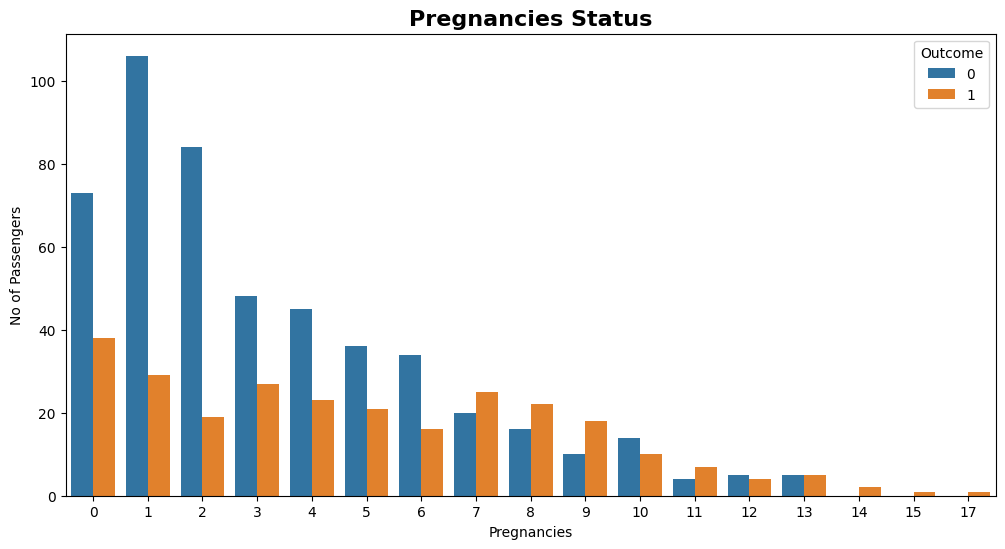

In [ ]:
plt.figure(figsize=(12,6))
plt.title("Pregnancies Status", fontsize=16, fontweight="bold")
plt.xlabel("Pregnancies")
plt.ylabel("No of Passengers")
sns.countplot(data=df, x="Pregnancies", hue='Outcome')
plt.show()


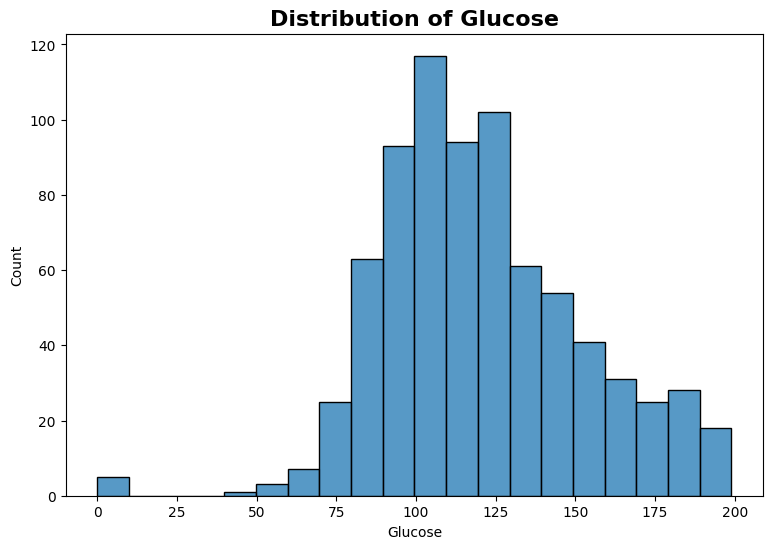

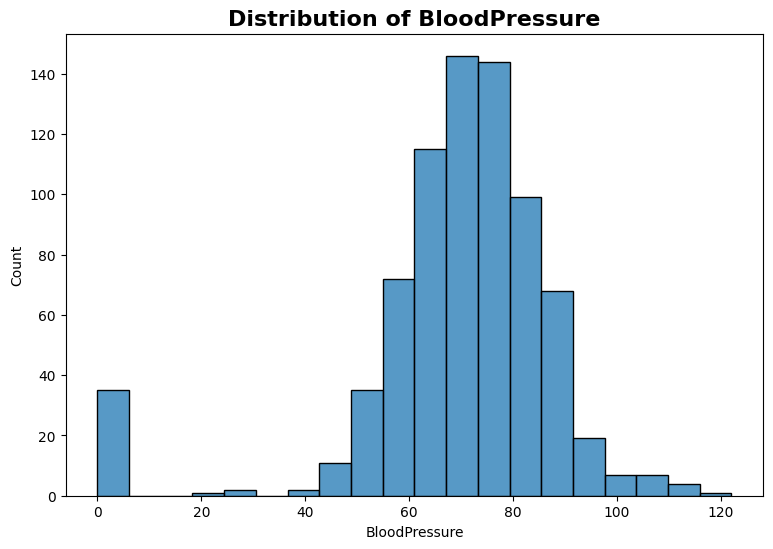

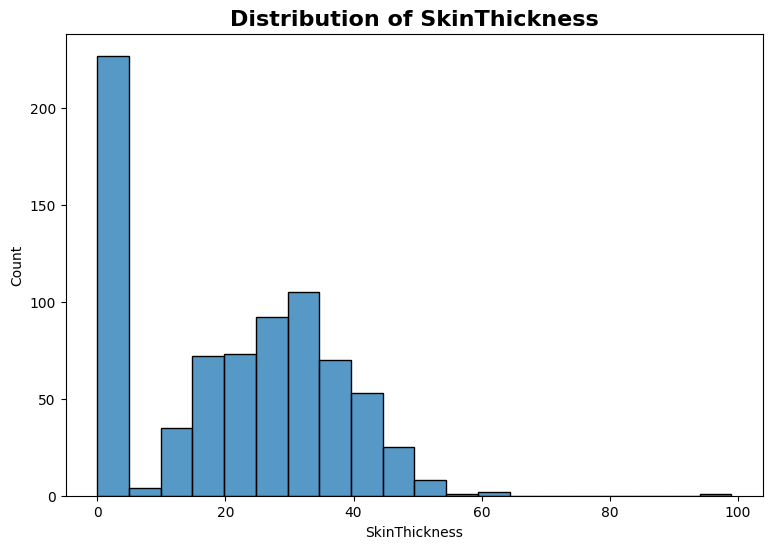

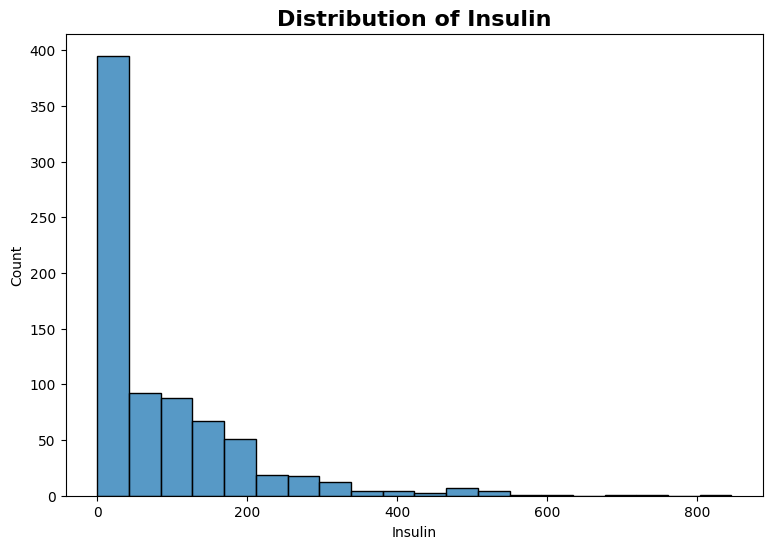

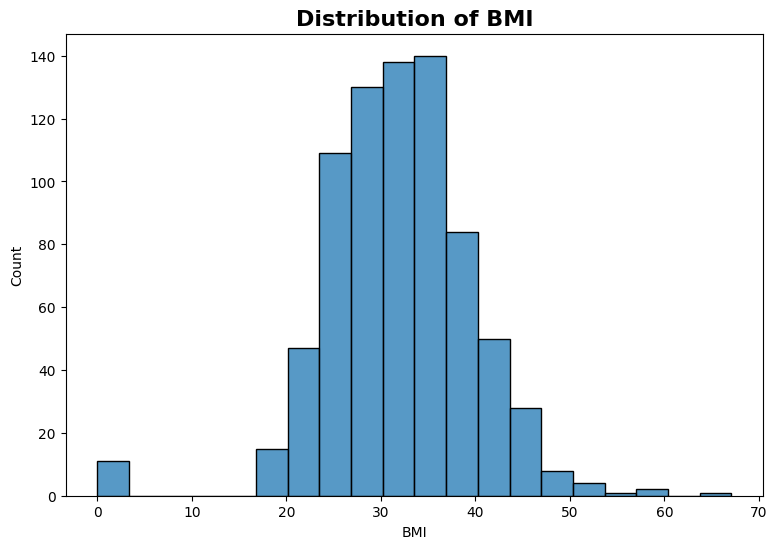

In [ ]:
columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin','BMI',]

for col in columns:
  plt.figure(figsize=(9, 6))
  plt.title(f"Distribution of {col}", fontsize=16, fontweight="bold")
  plt.xlabel(col)
  sns.histplot(data=df, x=col, bins=20)
  plt.show()

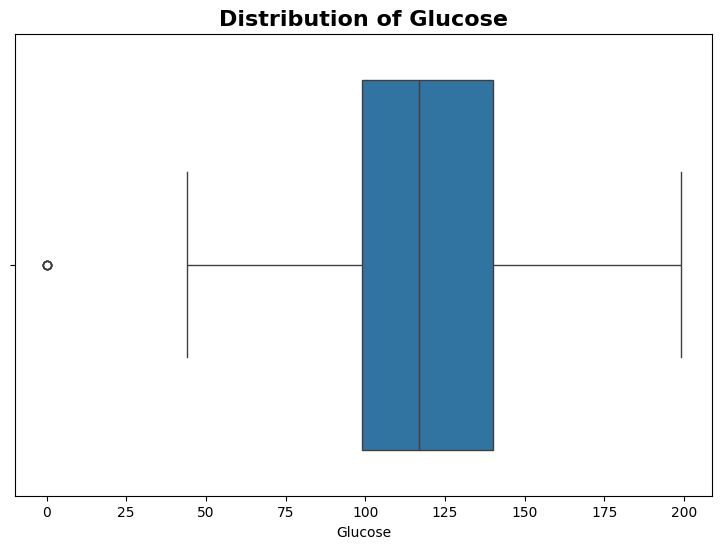

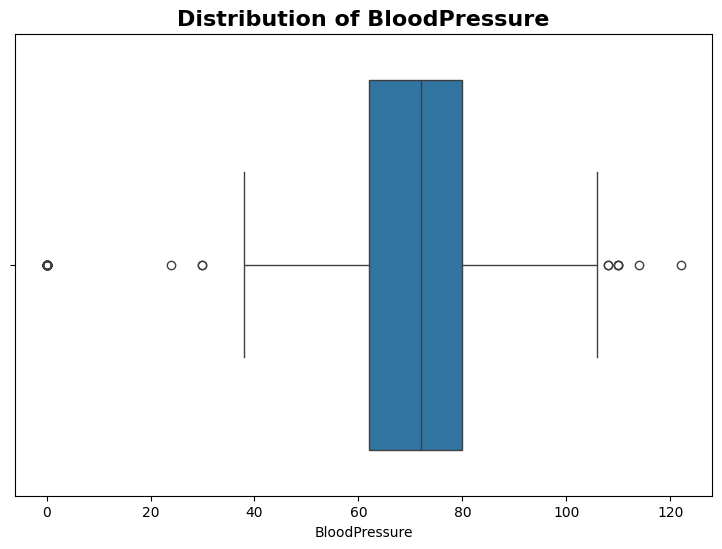

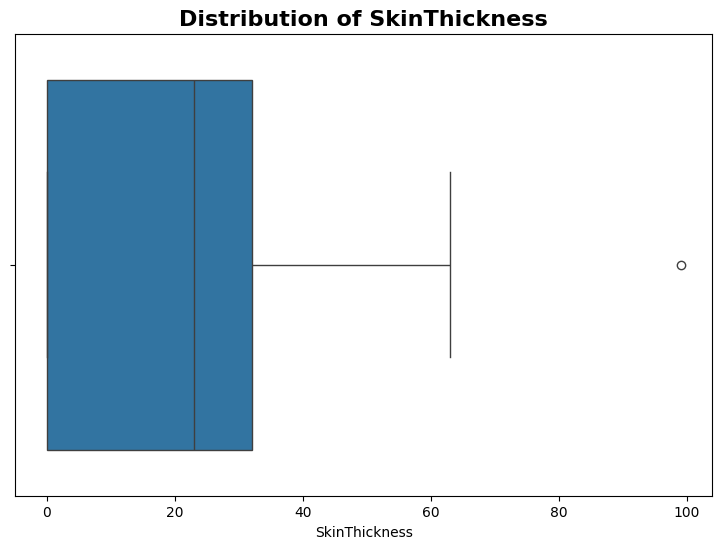

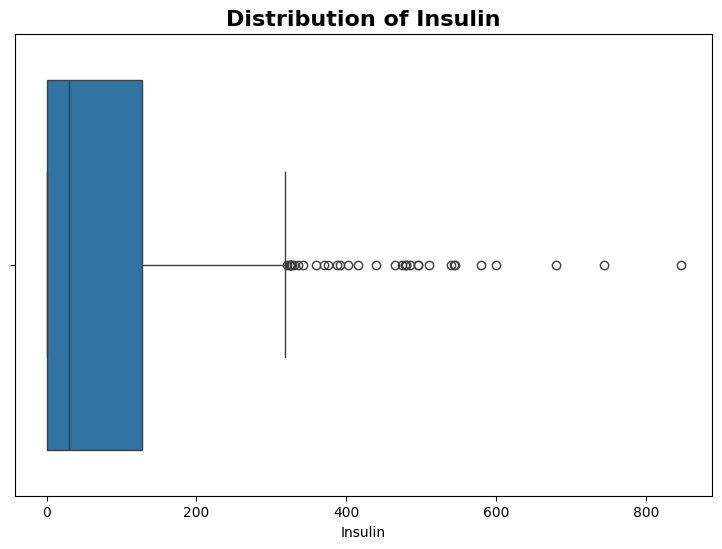

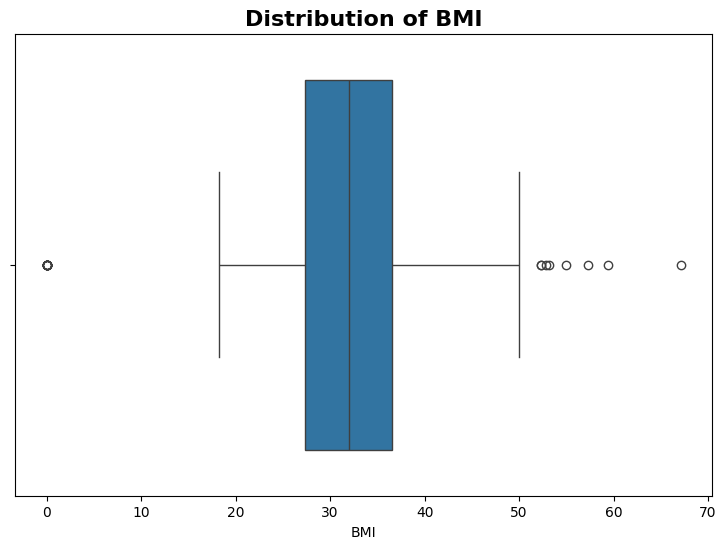

In [ ]:
for col in columns:
  plt.figure(figsize=(9, 6))
  plt.title(f"Distribution of {col}", fontsize=16, fontweight="bold")
  plt.xlabel(col)
  sns.boxplot(data=df, x=col)
  plt.show()

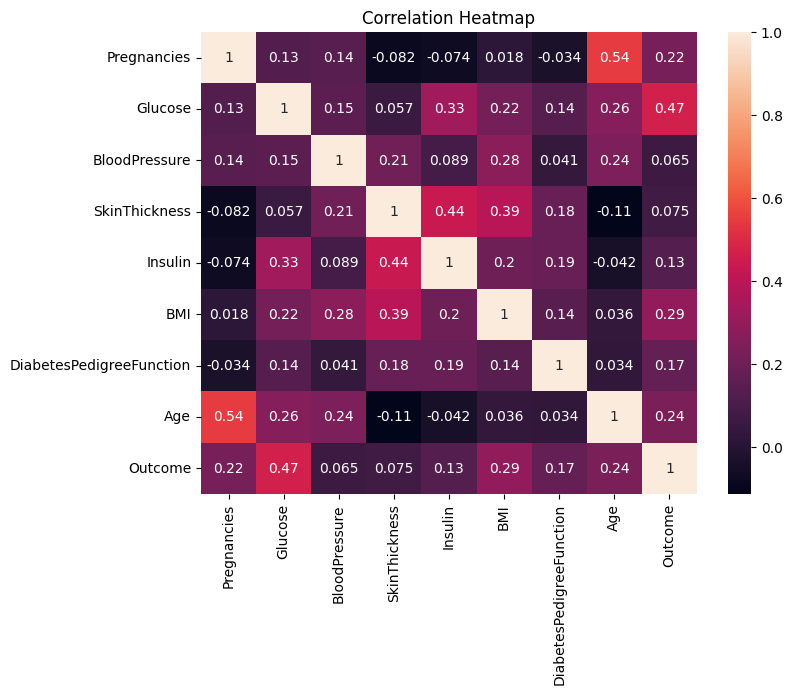

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# PREPROCESSING

In [ ]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols:
    df[col] = df[col].replace(0, df[col].median())

In [ ]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
pipeline = Pipeline([
    ('yeo_johnson_scaler', PowerTransformer(method='yeo-johnson', standardize=True)),
])

In [ ]:
X_train_scaled = pipeline.fit_transform(X_train)
X_test_scaled = pipeline.transform(X_test)

In [ ]:
model = LogisticRegression()

In [ ]:
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
y_pred = pd.DataFrame(model.predict(X_test_scaled), columns=['Prediction'])
y_pred_prob = pd.DataFrame(model.predict_proba(X_test_scaled), columns=['Probability Of Not Diabetic', 'Probability of Diabetic"'])

In [ ]:
y_pred_prob.rename(columns={0:'Probability Of Not Diabetic',
                    1: 'Probability of Diabetic'})

,Probability Of Not Diabetic,"Probability of Diabetic"""
0,0.680586,0.319414
1,0.889659,0.110341
2,0.931461,0.068539
3,0.828427,0.171573
4,0.520415,0.479585
...,...,...
149,0.245236,0.754764
150,0.919779,0.080221
151,0.495498,0.504502
152,0.707698,0.292302


In [ ]:
result = pd.concat([y_pred, y_pred_prob], axis=1)

In [ ]:
result

,Prediction,Probability Of Not Diabetic,"Probability of Diabetic"""
0,0,0.680586,0.319414
1,0,0.889659,0.110341
2,0,0.931461,0.068539
3,0,0.828427,0.171573
4,0,0.520415,0.479585
...,...,...,...
149,1,0.245236,0.754764
150,0,0.919779,0.080221
151,1,0.495498,0.504502
152,0,0.707698,0.292302


In [ ]:
acc = accuracy_score(y_pred=y_pred, y_true=y_test)

In [ ]:
acc

0.7597402597402597

In [ ]:
def new_prediction(arr: list) -> str:
    io = np.array([arr])

    scaled_io = pipeline.transform(io)

    pred = model.predict(scaled_io)[0]

    pred_prob = model.predict_proba(scaled_io)[0]
    prob_not_diabetic = pred_prob[0]
    prob_diabetic = pred_prob[1]

    return f"Prediction: {'Diabetic' if pred == 1 else 'Not Diabetic'} | Probability of Diabetic: {prob_diabetic*100:.2f} | Probability of Not Diabetic: {prob_not_diabetic*100:.2f}"


In [ ]:
arr = [1,	65,	66,	29,	32,	26.6,	0.351,	31]

print(new_prediction(arr))

Prediction: Not Diabetic | Probability of Diabetic: 1.74 | Probability of Not Diabetic: 98.26
